In [1]:
import os

os.chdir('/home/slagter/Astronomy_master/STRW-MSC/SF_in_NGC')
from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd
import scripts.phot_toolkits as phot_tk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt,  matplotlib.gridspec as gridspec

from astropy.io import fits
from astropy.io import ascii
from astropy.stats import knuth_bin_width
from pathlib import Path
import csv
%load_ext autoreload
%autoreload 2

from astropy import wcs
import astropy.units as u
from astropy.coordinates import SkyCoord


from astropy.visualization import ZScaleInterval
from astropy.wcs import WCS
from reproject import reproject_interp

level3_data_path = '/net/vdesk/data2/slagter/JWST_NIRCAM_#1227_level_3/'

from astropy.visualization import (ZScaleInterval, AsinhStretch,
                                   ImageNormalize, make_lupton_rgb)

from matplotlib.colors import to_rgb
    

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


In [2]:
def find_center( ny, nx, wcs ):
    return wcs.pixel_to_world((nx - 1) / 2, (ny - 1) / 2)

def make_target_wcs(center, dra, ddec, rot, width, height, pix_scale):
    new_center = center.spherical_offsets_by(dra, ddec)
    n_x = int((width  / pix_scale).decompose())
    n_y = int((height / pix_scale).decompose())
    th  = rot.to_value(u.rad)

    target = WCS(naxis=2)
    target.wcs.ctype = ['RA---TAN', 'DEC--TAN']
    target.wcs.crval = [new_center.ra.deg, new_center.dec.deg]
    target.wcs.crpix = [n_x / 2 + 0.5, n_y / 2 + 0.5]
    target.wcs.cdelt = [-pix_scale.to_value(u.deg), pix_scale.to_value(u.deg)]
    target.wcs.pc    = [[np.cos(th), -np.sin(th)],
                        [np.sin(th),  np.cos(th)]]
    return target, (n_y, n_x)

def load_image_color(filt, target, shape_out):
    """
    Reproject single mosaic into chosen grid
    """
    level3_data_path = '/net/vdesk/data2/slagter/JWST_NIRCAM_#1227_level_3/'
    with fits.open(level3_data_path + f'mosaic_{filt}_final_i2d.fits', memmap=True) as hdu:
        data = hdu['SCI'].data
        w    = WCS(hdu['SCI'].header, hdu)
        img, _ = reproject_interp((data, w), target, shape_out=shape_out)
    return img

def plot_mosaic(filter      = 'F115W',
                center      = SkyCoord(ra=14.95176547*u.deg, dec=-72.21625529*u.deg,frame='icrs'), #the one from F187N
                dra         = 1 * u.arcmin, 
                ddec        = 0 * u.arcmin,
                rot         = 0 * u.deg,                    
                width       = 15 * u.arcmin,                
                height      = 15 * u.arcmin,
                pix_scale   = 0.5 * u.arcsec,             
                ):

    # center = find_center(*Image.shape, wcs= wcs_mosaic)
    # print(center)
    target, shape_out = make_target_wcs(center, dra, ddec, rot, width, height, pix_scale)
    Image             = load_image_color(filter, target, shape_out)

    fig = plt.figure(figsize=(7,7))
    gs = gridspec.GridSpec(1, 1, figure=fig)  # once, before the loop
    ax = fig.add_subplot(gs[0, 0], projection=target)

    interval            = ZScaleInterval()
    vmin, vmax          = interval.get_limits(Image)

    ax.imshow(Image, cmap='bone', vmin=vmin, vmax=vmax, origin='lower')
    ax.set_facecolor(plt.colormaps['bone'](0))
    ax.coords['ra'].set_axislabel('RA')
    ax.coords['dec'].set_axislabel('Dec')
    ax.grid(color='w', alpha=0.3)
    plt.savefig(f"Plots/Mosaic_{filter}_final.pdf", bbox_inches='tight')
    return

def plot_mosaic_rgb(filters   = ('F444W', 'F187N', 'F115W'),   # (R, G, B)
                    colors    = [to_rgb(c) for c in ["#6600ff", "#26ef3d", "#fe9409"]],
                    weights   = [1.0, 1.0, 1.0],
                    center    = SkyCoord(ra=14.95176547*u.deg, dec=-72.21625529*u.deg, frame='icrs'),
                    dra       = 1 * u.arcmin,
                    ddec      = 0 * u.arcmin,
                    rot       = 0 * u.deg,
                    width     = 15 * u.arcmin,
                    height    = 15 * u.arcmin,
                    pix_scale = 0.5 * u.arcsec,
                    ):

    target, shape_out = make_target_wcs(center, dra, ddec, rot, width, height, pix_scale)

    # Format into the targed grid
    images_per_filter = [load_image_color(f, target, shape_out) for f in filters]
    
    # Build three color channels
    R = sum(w * c[0] * im for w, c, im in zip(weights, colors, images_per_filter))
    G = sum(w * c[1] * im for w, c, im in zip(weights, colors, images_per_filter))
    B = sum(w * c[2] * im for w, c, im in zip(weights, colors, images_per_filter))

    vmin, vmax = np.nanpercentile(np.stack([R, G, B]), [10, 99.7])
    rgb = make_lupton_rgb(R, G, B,
                        minimum=vmin,
                        stretch=(vmax - vmin) * 0.5,
                        Q=8)
    
    fig = plt.figure(figsize=(7, 7))
    ax  = fig.add_subplot(111, projection=target)
    ax.imshow(rgb, origin='lower')
    ax.coords['ra'].set_axislabel('RA')
    ax.coords['dec'].set_axislabel('Dec')
    ax.grid(color='w', alpha=0.3)
    fig.savefig(f"Plots/Mosaic_{'_'.join(filters)}_RGB.pdf", bbox_inches='tight')
    return rgb

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(4800, 4200, 3), dtype=uint8)

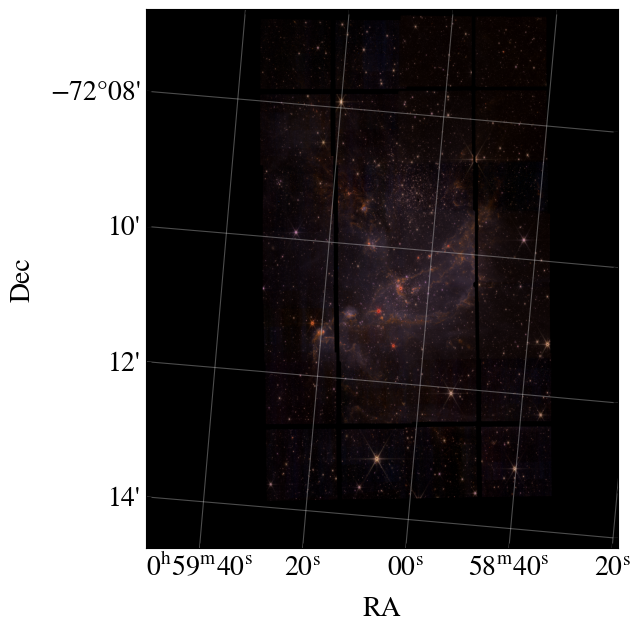

In [24]:
filters     = ('F444W', 'F335M', 'F277W', 'F200W','F187N', 'F115W')   # (R, G, B)
colors      = [to_rgb(c) for c in ["#ff0c28", "#ff8401","#e7b84b","#92F67C", "#003dc0", "#b453f5"]]
#colors      = [to_rgb(c) for c in ["#E45E5E", "#FF8400","#95FF00","#4FE2EA","#00D0FF", "#9D00FF"]]
weights     = [1.0, 1.0, 0.5, 1, 0.2, 1]

plot_mosaic_rgb(filters     = filters,
                center      = SkyCoord(ra=14.95176547*u.deg, dec=-72.21625529*u.deg,frame='icrs'), #the one from F187N
                colors      = colors,
                weights     = weights,
                dra         = -3    * u.arcmin,    # shift east / north
                ddec        = 2.5   * u.arcmin,
                rot         = 5     * u.deg,       # rotation of the view (0 = north up)
                width       = 7     * u.arcmin,    # field of view
                height      = 8     * u.arcmin,
                pix_scale   = 0.1     * u.arcsec,    # output pixel size
                )

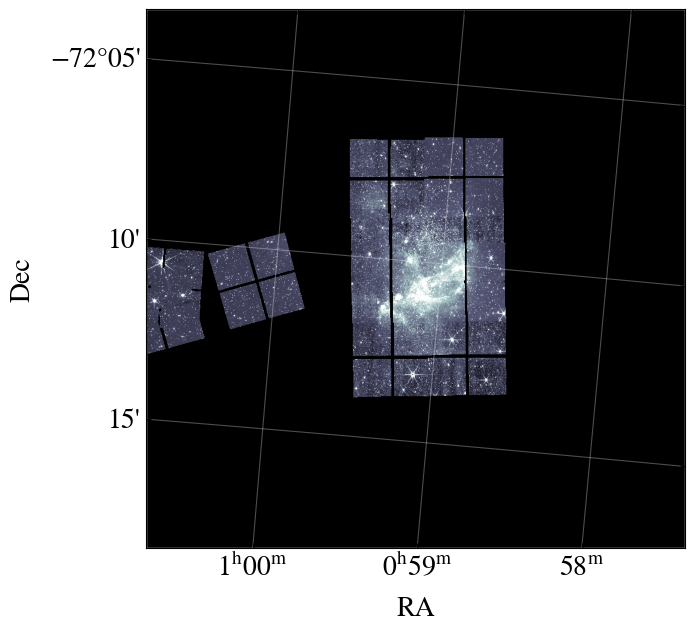

In [4]:
plot_mosaic(    filter      = 'F200W',
                dra         = -3    * u.arcmin,    # shift east / north
                ddec        = 2.5   * u.arcmin,
                rot         = 5     * u.deg,       # rotation of the view (0 = north up)
                width       = 15     * u.arcmin,    # field of view
                height      = 15     * u.arcmin,
                pix_scale   = 1   * u.arcsec,    # output pixel size
)

In [ ]:
def Split_Mosaic_on_WHT(mosaic_path = level3_data_path + 'mosaic_F115W_final_i2d.fits',
                        wht_threshold = 200.0):
    
    hdu = fits.open(mosaic_path)  
        
    # Build masks & Apply
    wht_data = hdu['WHT'].data
    long_exposure_mask      = wht_data > wht_threshold
    short_exposure_mask     = ~long_exposure_mask  
    long_exposure_data      = []
    short_exposure_data     = []

    for fit_frame in ['SCI', 'ERR',  'WHT', 'VAR_POISSON','VAR_RNOISE', 'VAR_FLAT']: #con
        data    = hdu[fit_frame].data
        header  = hdu[fit_frame].header
        long_exposure_data.append( fits.ImageHDU(data  = np.where(long_exposure_mask, data, np.nan).astype(data.dtype),
                 header=header, name=fit_frame))
        
        short_exposure_data.append( fits.ImageHDU(data = np.where(short_exposure_mask, data, np.nan).astype(data.dtype),
                 header=header, name=fit_frame))
        
    hdu_out = fits.HDUList([fits.PrimaryHDU(header  = hdu[0].header)] + long_exposure_data)
    hdu_out.writeto( level3_data_path + 'mosaic_F115W_long_exposure.fits', overwrite=True)
    
    hdu_out = fits.HDUList([fits.PrimaryHDU(header  = hdu[0].header)] + short_exposure_data)
    hdu_out.writeto( level3_data_path + 'mosaic_F115W_short_exposure.fits', overwrite=True)

    hdu.close()
    return

Split_Mosaic_on_WHT()



In [ ]:
hdu                 = fits.open(level3_data_path + 'mosaic_F115W_long_exposure.fits')
Image               = hdu[1].data
interval            = ZScaleInterval()
vmin, vmax          = interval.get_limits(Image)

plt.imshow(hdu['SCI'].data, cmap='BrBG_r',  vmin=vmin, vmax=vmax, origin='lower')
plt.colorbar()


hdu                 = fits.open(level3_data_path + 'mosaic_F115W_short_exposure.fits')
Image               = hdu[1].data
interval            = ZScaleInterval()
vmin, vmax          = interval.get_limits(Image)

plt.imshow(hdu['SCI'].data, cmap='BrBG_r',  vmin=vmin, vmax=vmax, origin='lower')
plt.colorbar()